# Horizontal disc flight — updated 0° results
Initial lab velocity (25,0,0) m/s, 1000 rpm, mass 100 g. Height = Z translation + assumed 1 m release height. Raw CSVs are unchanged. Run from this folder with NumPy and Matplotlib installed.

Plots retain intrinsic aspect ratio and show Z above Y. Positions and velocities are unfiltered. Coefficient/force display filter: mask absolute values above three times the post-0.05 s 95th percentile; consistent force thresholds use Q=0.5 rho Uref² A=11.6195 N. Masked samples remain in raw data and are not declared erroneous. No smoothing. Means are time-weighted over the final 0.20 s.

Reported coefficients and force directions are retained as exported; signed lab forces and wind-axis lift/drag need report-axis confirmation. No extrapolation to landing. Local pressure snapshots do not establish an integrated lateral force. Oscillations may involve physical or numerical effects; the motion records alone cannot prove gyroscopic precession.


{
  "time_s": 2.7199000000013154,
  "x_m": 52.41631459431407,
  "height_m": 0.05130129022602037,
  "y_cm": -6.092642844445758,
  "vx_m_s": 15.20876308791415,
  "rpm": 943.2241359515269,
  "peak_height_m": 1.0467962085018676,
  "means_last_0_2s": {
    "drag_coefficient": 0.019692493449692802,
    "frisbee_X_force": 0.22881637378732722,
    "lift_coefficient": 0.08255992004119451,
    "frisbee_Z_force": 0.9593026689209084
  },
  "filter": {
    "drag_coefficient": {
      "limit": 0.12664294509386764,
      "masked": 9
    },
    "frisbee_X_force": {
      "limit": 1.4715241386853641,
      "masked": 9
    },
    "lift_coefficient": {
      "limit": 0.27052825824338844,
      "masked": 5
    },
    "frisbee_Z_force": {
      "limit": 3.1433954880517887,
      "masked": 5
    }
  }
}


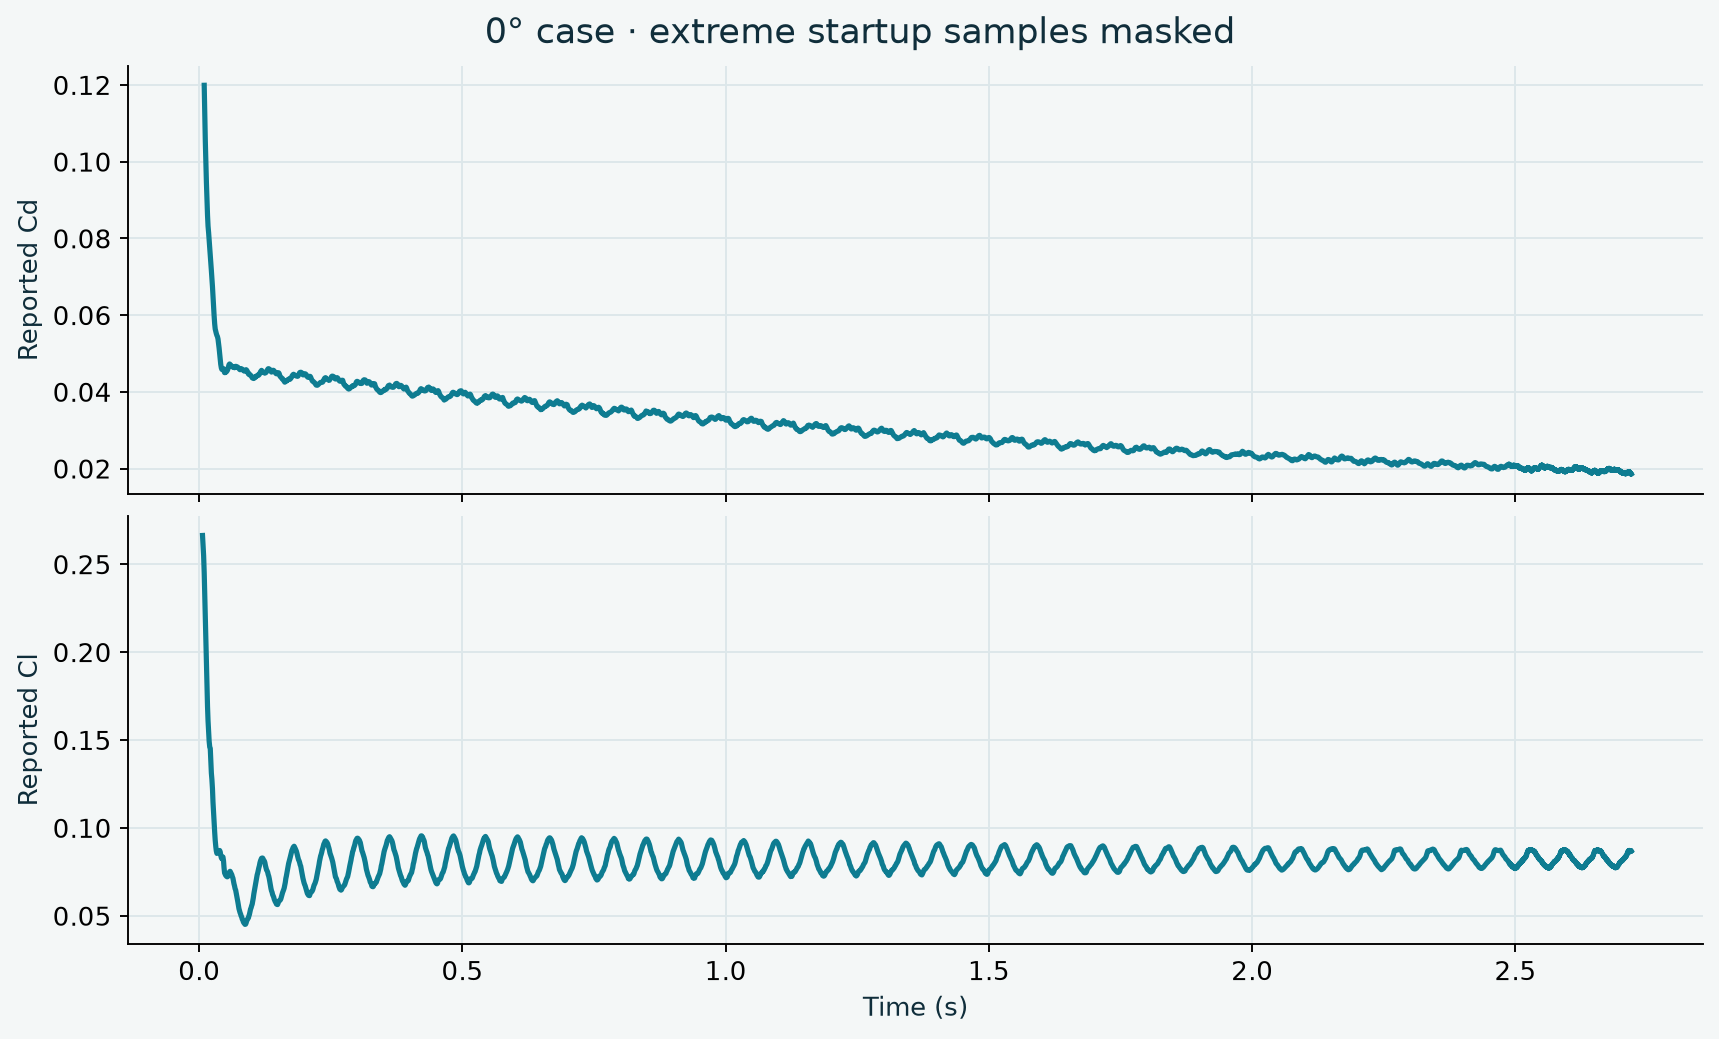

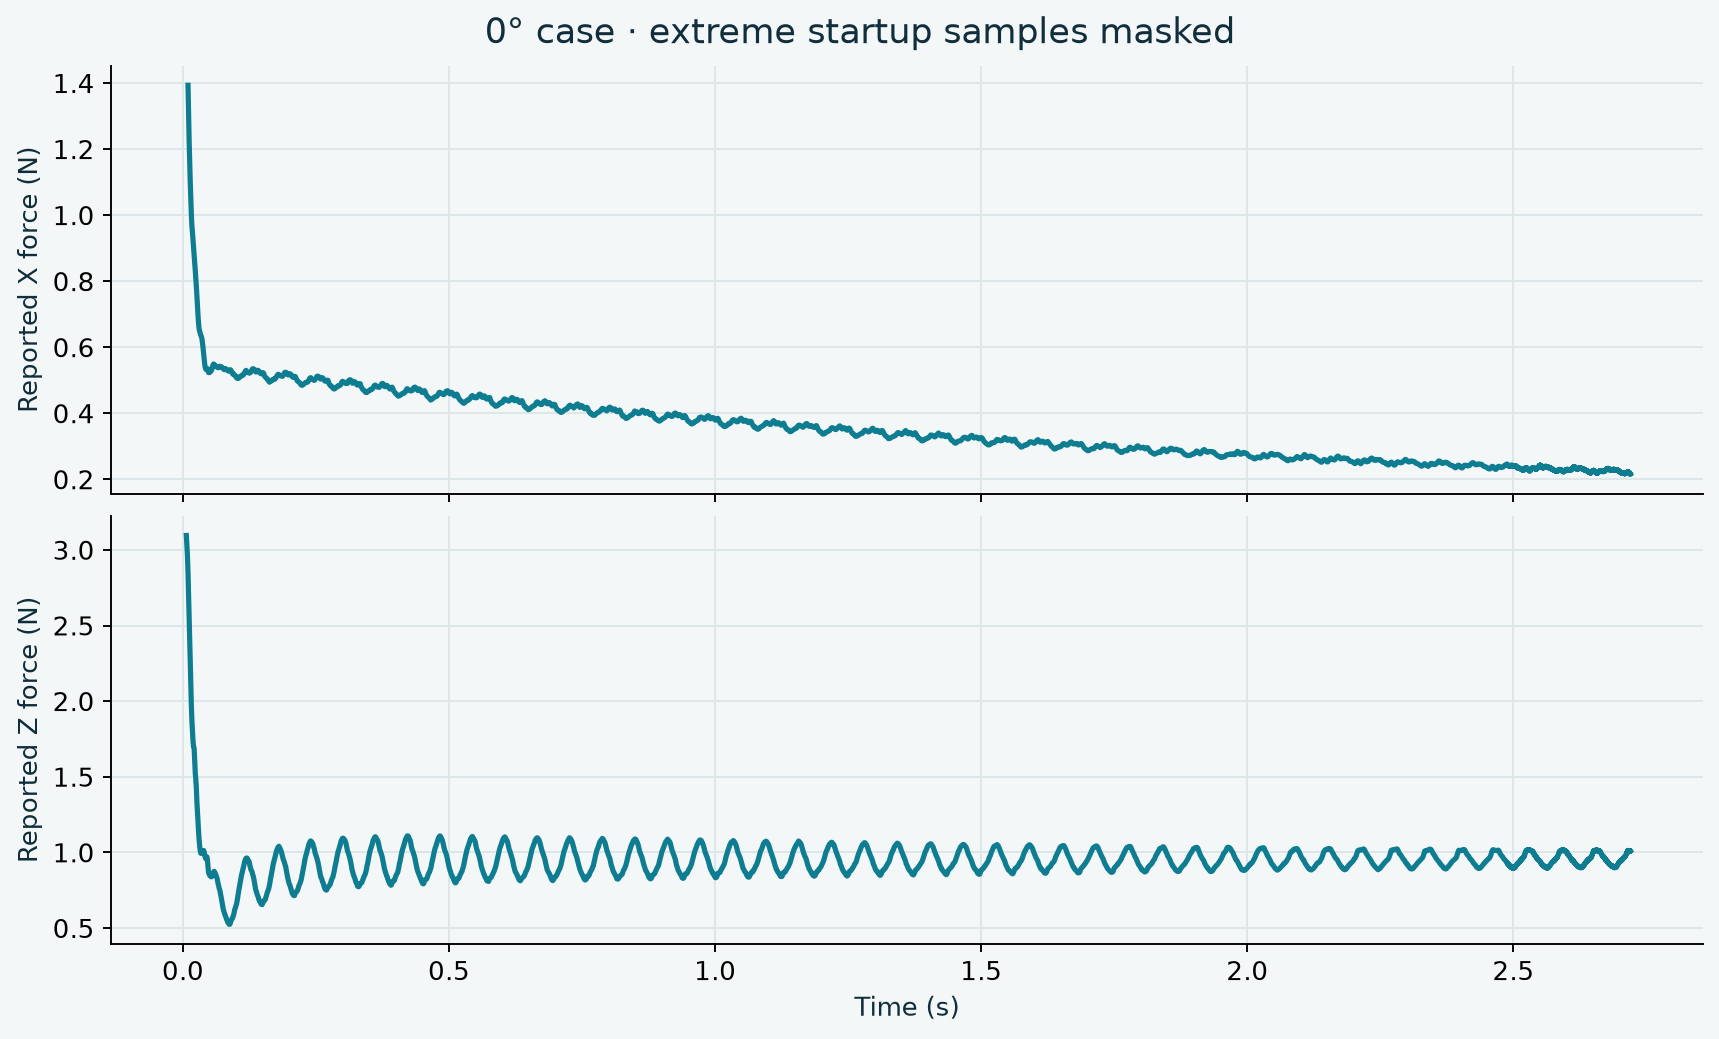

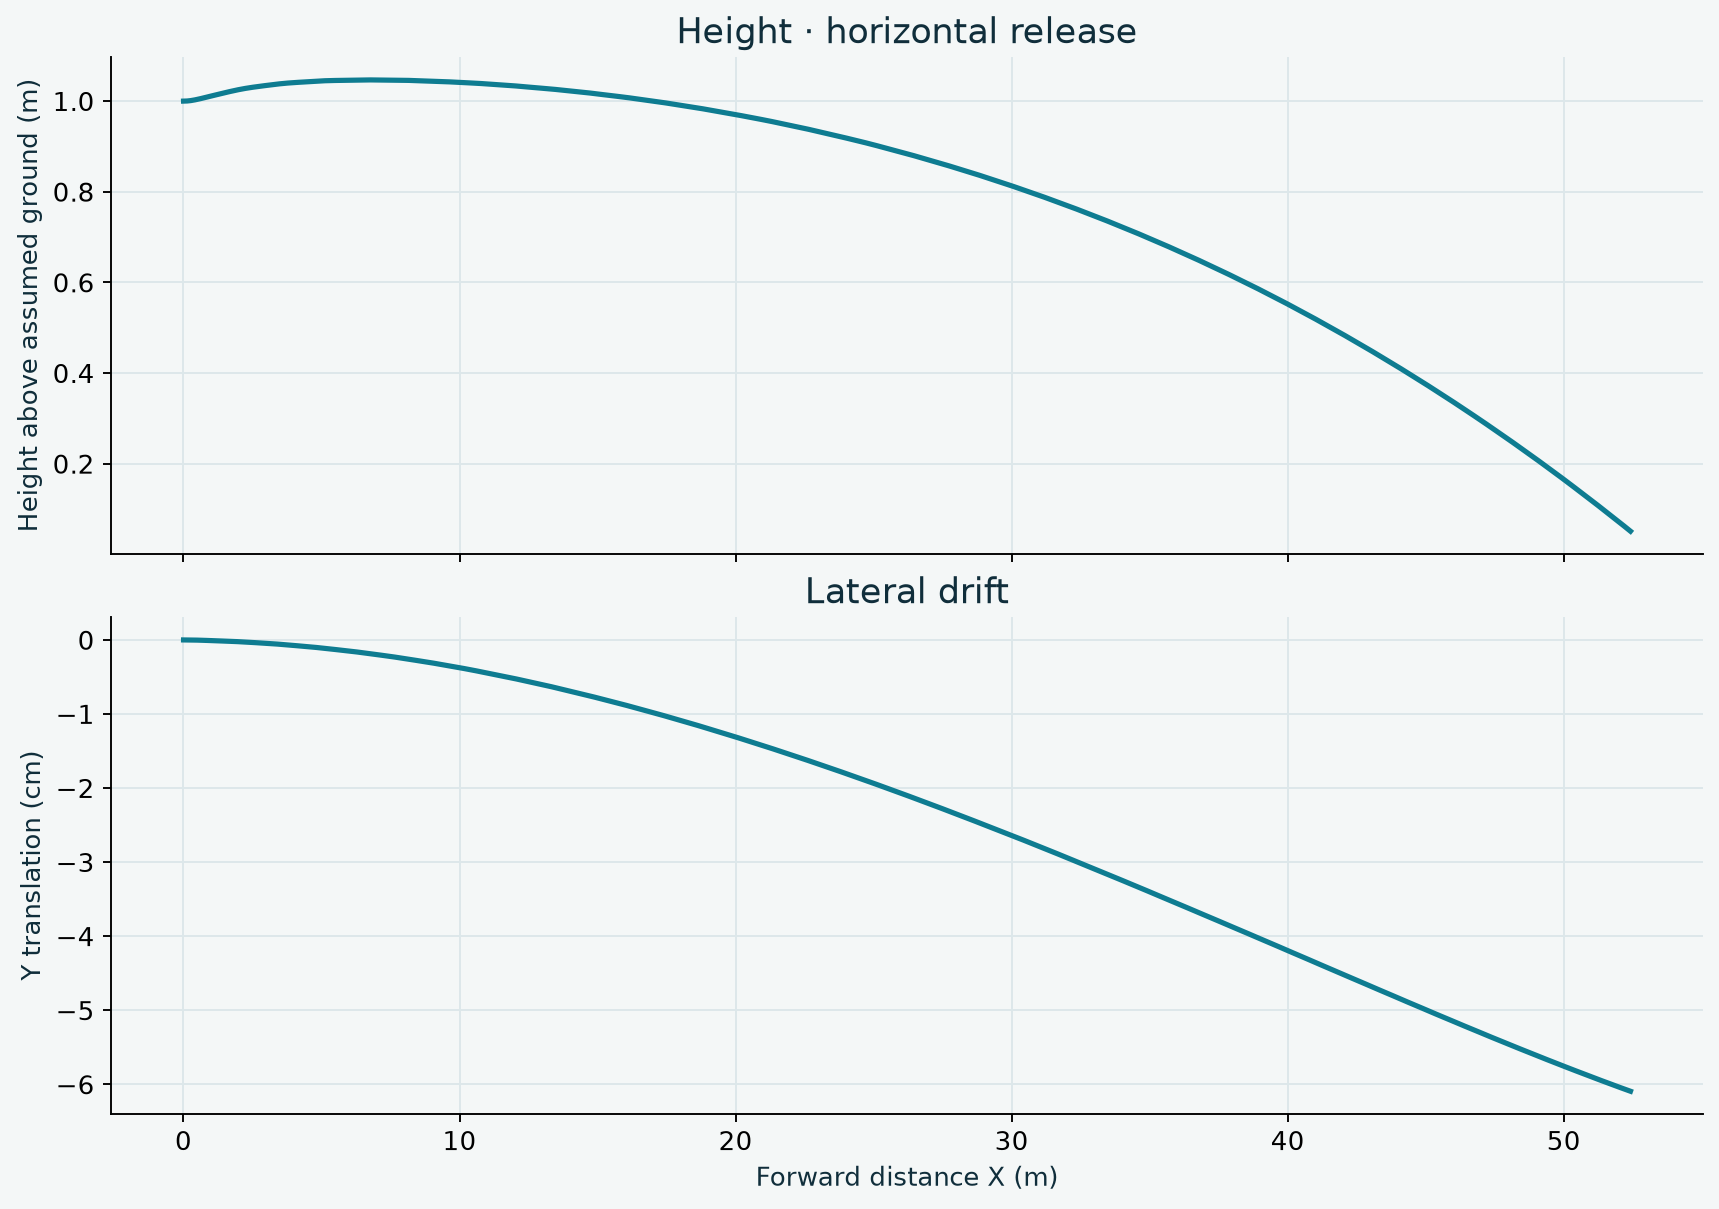

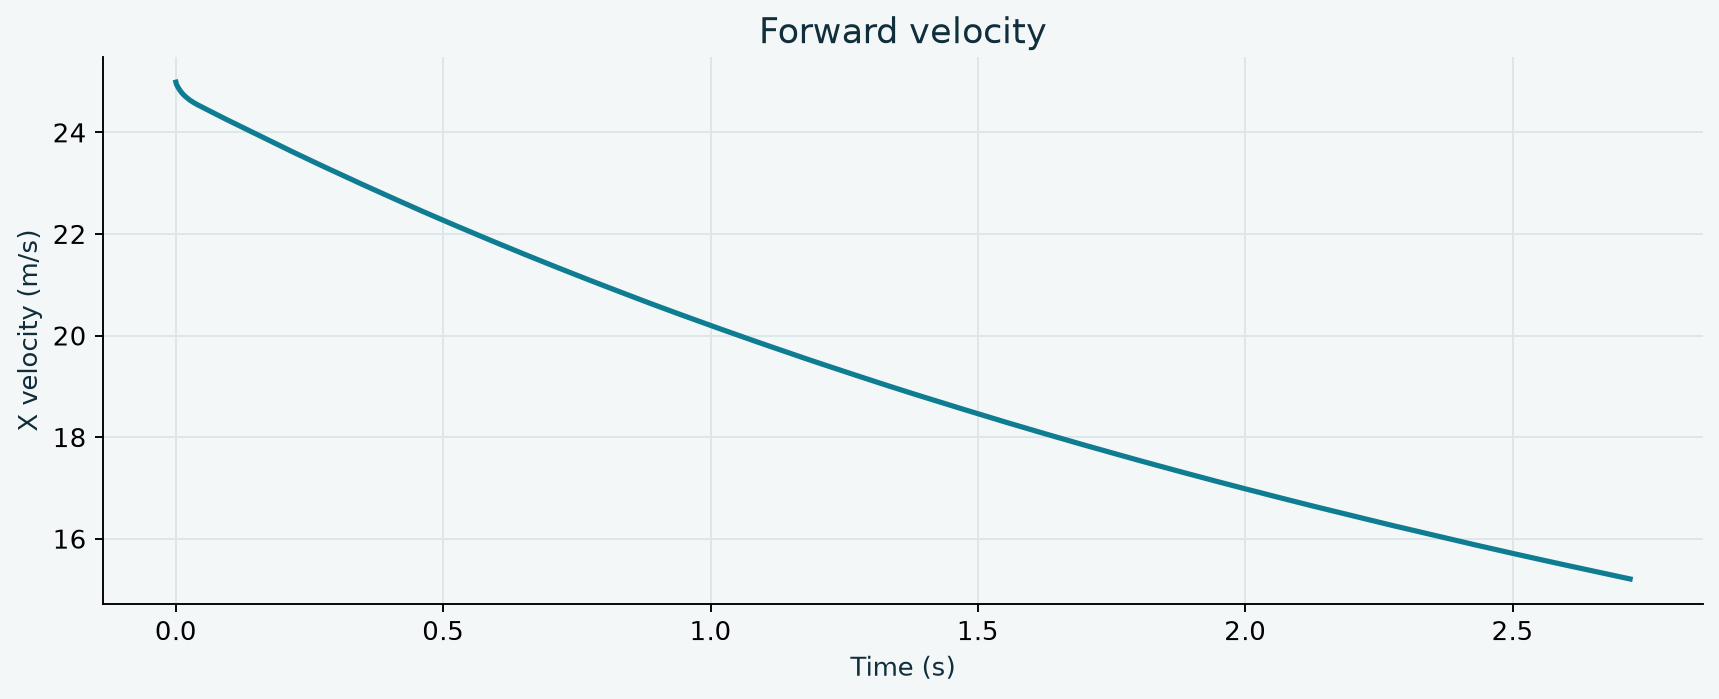

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import json
BASE=Path.cwd();PLOTS=BASE/'plots';PLOTS.mkdir(exist_ok=True)
d={p.stem:np.loadtxt(p,delimiter=',',skiprows=1) for p in (BASE/'data').glob('*.csv')}
for k,a in d.items():
 assert np.isfinite(a).all()
 if k!='XZ_position':assert np.all(np.diff(a[:,0])>0)
t,x=d['X_position'].T
z=np.interp(t,*d['Z_position'].T);y=np.interp(t,*d['Y_position'].T)
assert np.allclose(d['XZ_position'],np.column_stack([x,z]))
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'axes.titlesize':15,'text.color':'#102e3b','axes.labelcolor':'#102e3b','axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.color':'#dce7ea','figure.facecolor':'#f4f7f7','axes.facecolor':'#f4f7f7','lines.linewidth':2.2,'savefig.dpi':170})
def save(fig,name):
 fig.savefig(PLOTS/(name+'.png'),bbox_inches='tight');fig.savefig(PLOTS/(name+'.svg'),bbox_inches='tight');plt.show();plt.close(fig)
fig,ax=plt.subplots(2,1,figsize=(10,7),sharex=True,layout='constrained')
ax[0].plot(x,1+z,color='#0e7c91');ax[0].set(title='Height · horizontal release',ylabel='Height above assumed ground (m)')
ax[1].plot(x,100*y,color='#0e7c91');ax[1].set(title='Lateral drift',ylabel='Y translation (cm)',xlabel='Forward distance X (m)')
save(fig,'zero_trajectory')
fig,ax=plt.subplots(figsize=(10,4),layout='constrained');ax.plot(*d['X_velocity'].T,color='#0e7c91');ax.set(title='Forward velocity',xlabel='Time (s)',ylabel='X velocity (m/s)');save(fig,'zero_velocity')
Q=.5*1.18415*25**2*.0314
filtered={};audit={};means={}
for coeff,force in [('drag_coefficient','frisbee_X_force'),('lift_coefficient','frisbee_Z_force')]:
 a=d[coeff];limit=3*np.percentile(abs(a[a[:,0]>=.05,1]),95)
 for k,lim in [(coeff,limit),(force,limit*Q)]:
  a=d[k];mask=abs(a[:,1])>lim;v=a[:,1].copy();v[mask]=np.nan;filtered[k]=np.column_stack([a[:,0],v]);audit[k]={'limit':float(lim),'masked':int(mask.sum())}
  tx=np.r_[t[-1]-.2,a[(a[:,0]>t[-1]-.2)&(a[:,0]<t[-1]),0],t[-1]];vals=np.interp(tx,*filtered[k].T);assert np.isfinite(vals).all();means[k]=float(np.trapezoid(vals,tx)/.2)
for names,ylabs,file in [(['drag_coefficient','lift_coefficient'],['Reported Cd','Reported Cl'],'zero_coefficients'),(['frisbee_X_force','frisbee_Z_force'],['Reported X force (N)','Reported Z force (N)'],'zero_forces')]:
 fig,axes=plt.subplots(2,1,figsize=(10,6),sharex=True,layout='constrained')
 for ax,k,label in zip(axes,names,ylabs):ax.plot(*filtered[k].T,color='#0e7c91');ax.set(ylabel=label)
 axes[-1].set_xlabel('Time (s)');fig.suptitle('0° case · extreme startup samples masked',fontsize=15);save(fig,file)
stats={'time_s':float(t[-1]),'x_m':float(x[-1]),'height_m':float(1+z[-1]),'y_cm':float(100*y[-1]),'vx_m_s':float(d['X_velocity'][-1,1]),'rpm':float(d['RPM'][-1,1]),'peak_height_m':float(1+z.max()),'means_last_0_2s':means,'filter':audit}
assert np.all(1+z>0),'Landing reached: update text'
(BASE/'summary.json').write_text(json.dumps(stats,indent=2));print(json.dumps(stats,indent=2))
